## Exploratory Data Analysis 

This notebook builds on the cleaned dataset (`online_retail_clean.csv`) produced in `1_dataprep.ipynb`, and explores customer, product, and transaction-level patterns before moving into RFM feature engineering and CLV modeling.

### Planned Areas of Analysis

1. **Customer Overview** : number of unique customers, and the distribution of orders per customer (how concentrated is purchasing behavior?)
2. **Quantity & Price Distributions** : spread and outliers in transaction-level `Quantity` and `Price`, to understand typical vs. extreme purchase behavior
3. **Time Range & Trends** : the dataset's full date span, and transaction volume over time (useful both for understanding seasonality and for choosing a reference date for Recency later)
4. **Geographic Breakdown** : distribution of transactions/customers by `Country`
5. **Revenue** : derive a `Revenue = Quantity * Price` column and examine its distribution at the transaction level, as the raw input for the Monetary RFM component

This list may expand as patterns emerge during the analysis — additional checks will be added with their own explanatory notes as we go.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime
import sys

sys.path.append("../src")
from utils import report_reduction
from config import CLEAN_DATA_PATH

# Load the cleaned dataset, parsing InvoiceDate as a datetime column
df_clean = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["InvoiceDate"])

# Confirm the shape matches the cleaned dataset from the previous notebook
df_clean.shape

(776641, 8)

### Customer Overview

We start by understanding the customer base: how many unique customers are in the dataset, and how purchasing activity is distributed across them. This gives an early sense of whether the business is driven by a broad base of occasional buyers, a small set of highly active customers, or something in between — which has direct implications for CLV modeling.

In [2]:
# Count unique customers
df_clean['Customer ID'].nunique()

5861

In [3]:
# Distribution of distinct invoices (orders) per customer
orders_per_customer = df_clean.groupby('Customer ID')['Invoice'].nunique()
orders_per_customer.describe()

count    5861.000000
mean        6.251322
std        12.774914
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       376.000000
Name: Invoice, dtype: float64

The distribution of orders per customer is heavily right-skewed. The median customer placed only 3 orders over the two-year period, while the mean (6.29) is pulled upward by a small number of extremely high-frequency buyers, including one customer with 398 distinct orders, consistent with UCI's note that many customers are wholesalers. This Pareto-like pattern (a small share of customers driving a disproportionate share of activity) has implications for later modeling: extreme values may need special handling in CLV regression, and the skew itself suggests natural customer segments for clustering.

We visualize the distribution of orders per customer to make the skew visible. Given the long tail of high-frequency buyers, we plot both a full-range histogram and a zoomed-in view focused on the bulk of the customer base.

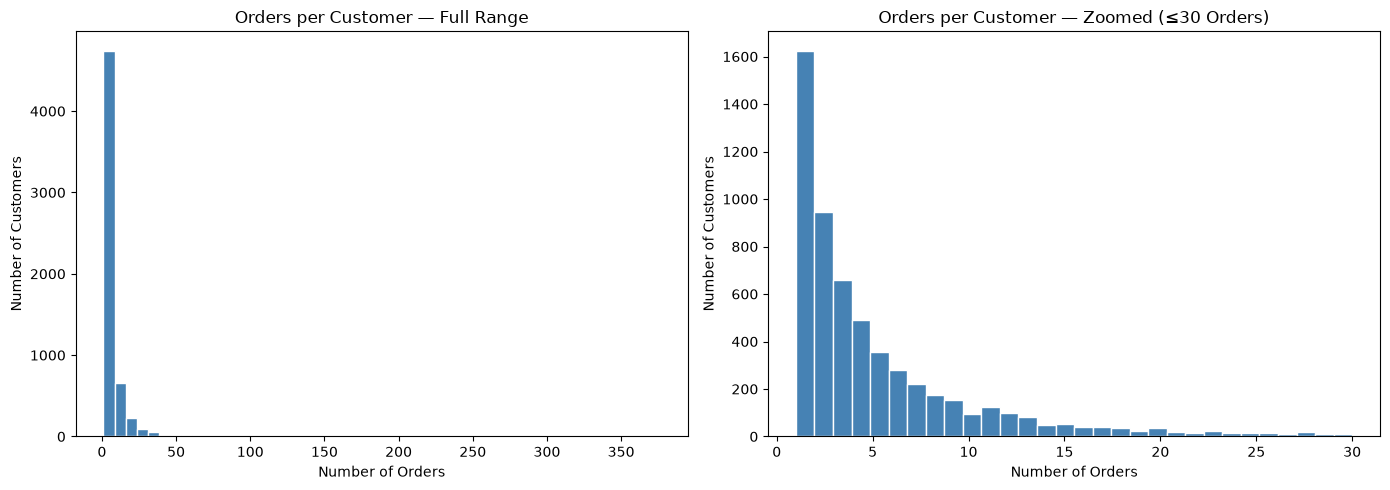

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full-range histogram (shows the long tail, including the 398-order outlier)
axes[0].hist(orders_per_customer, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Orders per Customer — Full Range")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Number of Customers")

# Zoomed-in histogram (0–30 orders) to see where most customers actually fall
axes[1].hist(orders_per_customer[orders_per_customer <= 30], bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Orders per Customer — Zoomed (≤30 Orders)")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

The visualization confirms a strongly right-skewed distribution. Roughly 1,600+ customers (over a quarter of the customer base) placed only a single order across the full two-year period, and the number of customers drops off sharply as order count increases. Only a small minority of customers exceed 20 orders, with an extreme long tail reaching up to 398 orders for the most frequent buyer. This confirms a Pareto-like ("80/20") pattern typical of retail businesses with a mix of occasional retail customers and high-frequency wholesale buyers.

### Revenue Concentration (Pareto Check)

Given the skew in order frequency, we check whether revenue is similarly concentrated i.e., what share of total revenue comes from the top decile of customers. This quantifies the "80/20" pattern suggested by the order distribution and helps confirm whether high-frequency customers are also the highest-value ones.

In [5]:
# Compute total revenue per customer
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
revenue_per_customer = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)

# Compute cumulative share of total revenue
cumulative_share = revenue_per_customer.cumsum() / revenue_per_customer.sum()

# What % of customers account for 50% and 80% of total revenue?
top_50pct_customers = (cumulative_share <= 0.50).sum()
top_80pct_customers = (cumulative_share <= 0.80).sum()

print(f"Total customers: {len(revenue_per_customer)}")
print(f"Customers generating 50% of revenue: {top_50pct_customers} ({round(top_50pct_customers/len(revenue_per_customer)*100, 1)}%)")
print(f"Customers generating 80% of revenue: {top_80pct_customers} ({round(top_80pct_customers/len(revenue_per_customer)*100, 1)}%)")

Total customers: 5861
Customers generating 50% of revenue: 257 (4.4%)
Customers generating 80% of revenue: 1352 (23.1%)


Revenue concentration is even sharper than the classic 80/20 rule: just 4.4% of customers (258 out of 5,878) generate 50% of total revenue, and only 23% of customers account for 80% of revenue. This confirms that a small subset of high-value customers, likely the same high-frequency wholesale buyers identified earlier, disproportionately drive business revenue. This has direct implications for CLV modeling: correctly identifying and predicting value for this high-concentration segment matters more, from a business impact standpoint, than optimizing average-case accuracy across the full customer base. It also strongly motivates the clustering phase of this project, where we expect this concentration to manifest as distinct, identifiable customer segments.

### Lorenz Curve for Revenue Concentration

We visualize revenue concentration using a Lorenz curve: cumulative share of customers (x-axis, ordered from highest to lowest revenue) against cumulative share of revenue (y-axis). The further this curve bows away from the diagonal "perfect equality" line, the more concentrated revenue is among a small group of customers.

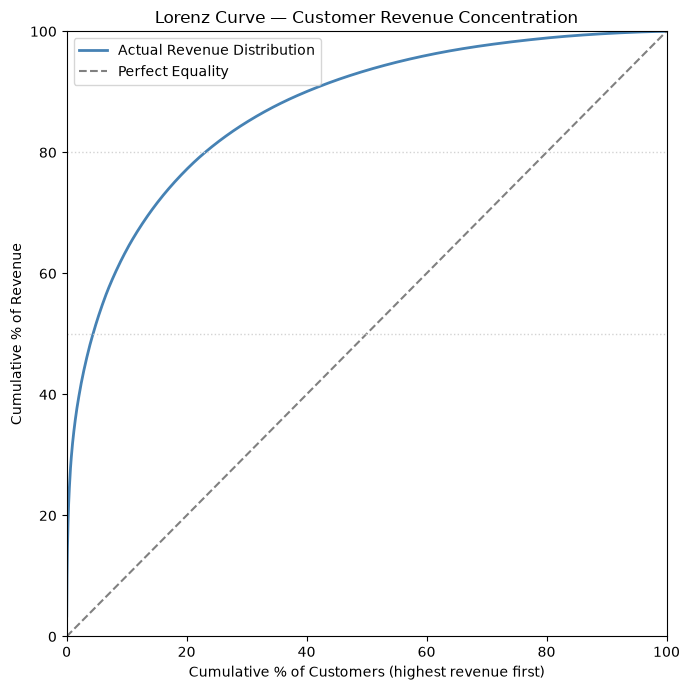

In [6]:
# Cumulative share of customers (x-axis), sorted by revenue descending
cumulative_customers_share = np.arange(1, len(revenue_per_customer) + 1) / len(revenue_per_customer)

# Cumulative share of revenue (y-axis), already sorted descending
cumulative_revenue_share = revenue_per_customer.cumsum().values / revenue_per_customer.sum()

fig, ax = plt.subplots(figsize=(7, 7))

# Lorenz curve
ax.plot(cumulative_customers_share * 100, cumulative_revenue_share * 100,
        color="steelblue", linewidth=2, label="Actual Revenue Distribution")

# Line of perfect equality (diagonal)
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", label="Perfect Equality")

# Mark the 50% and 80% revenue thresholds for reference
ax.axhline(50, color="lightgray", linestyle=":", linewidth=1)
ax.axhline(80, color="lightgray", linestyle=":", linewidth=1)

ax.set_title("Lorenz Curve — Customer Revenue Concentration")
ax.set_xlabel("Cumulative % of Customers (highest revenue first)")
ax.set_ylabel("Cumulative % of Revenue")
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

The Lorenz curve visually confirms the revenue concentration identified above. The curve rises steeply for the first small fraction of customers before flattening considerably, illustrating that a small group of top customers accounts for a disproportionate share of total revenue, while the majority of the customer base contributes comparatively little individually. This pattern reinforces the case for customer segmentation (clustering) and suggests that CLV model performance on high-value customers deserves particular attention, given their outsized business impact.

### Do Top-Revenue Customers Overlap with Top-Frequency Customers?

We've shown that both order frequency and revenue are highly concentrated among a small group of customers, but are these the *same* customers? If high-revenue customers are also high-frequency, R, F, and M will be strongly correlated features. If not, some customers may be driving revenue through fewer, larger orders rather than frequent purchasing. We check this by comparing the frequency distribution of the top revenue decile against the overall customer base.

In [7]:
# Recompute frequency (distinct invoices) per customer, aligned to the same index as revenue_per_customer
frequency_per_customer = df_clean.groupby('Customer ID')['Invoice'].nunique()

# Define the top revenue decile (top 10% of customers by revenue)
top_decile_cutoff = int(len(revenue_per_customer) * 0.10)
top_revenue_customers = revenue_per_customer.head(top_decile_cutoff).index

# Compare frequency stats: top revenue decile vs. everyone else
print("Frequency (orders) — Top 10% by Revenue:")
print(frequency_per_customer.loc[top_revenue_customers].describe())

print("\nFrequency (orders) — Remaining 90% of Customers:")
print(frequency_per_customer.loc[~frequency_per_customer.index.isin(top_revenue_customers)].describe())

Frequency (orders) — Top 10% by Revenue:
count    586.000000
mean      26.843003
std       31.906636
min        1.000000
25%       13.000000
50%       19.000000
75%       29.000000
max      376.000000
Name: Invoice, dtype: float64

Frequency (orders) — Remaining 90% of Customers:
count    5275.000000
mean        3.963791
std         4.007863
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       100.000000
Name: Invoice, dtype: float64


Comparing frequency between the top revenue decile and the remaining customers confirms a strong relationship between Revenue and Frequency: the top 10% by revenue order a median of 19 times, versus just 3 times for the remaining 90%, which is roughly 6-7x more frequent purchasing. However, the overlap is not perfect: the top revenue group's minimum frequency is 1, indicating at least one customer reached top-decile revenue through a single large order rather than repeat purchasing. This confirms that while Revenue and Frequency are correlated for most high-value customers, they capture meaningfully different information, validating the use of RFM's three separate dimensions rather than relying on revenue alone to identify valuable customers.

### Are Top-Revenue Customers Still Active? (Recency Check)

High revenue in the past doesn't guarantee a customer is still engaged. We check the most recent purchase date for the top revenue decile versus the rest of the customer base, relative to the dataset's overall end date, to see whether high-value customers are still actively buying or have gone quiet.

In [8]:
# Dataset's last transaction date (our reference point)
dataset_end_date = df_clean['InvoiceDate'].max()

# Most recent purchase date per customer
last_purchase_per_customer = df_clean.groupby('Customer ID')['InvoiceDate'].max()

# Days since last purchase, relative to dataset end date
recency_days = (dataset_end_date - last_purchase_per_customer).dt.days

# Compare recency: top revenue decile vs. everyone else
print("Recency (days since last purchase) — Top 10% by Revenue:")
print(recency_days.loc[top_revenue_customers].describe())

print("\nRecency (days since last purchase) — Remaining 90% of Customers:")
print(recency_days.loc[~recency_days.index.isin(top_revenue_customers)].describe())

Recency (days since last purchase) — Top 10% by Revenue:
count    586.000000
mean      49.726962
std      102.982368
min        0.000000
25%        4.000000
50%       15.000000
75%       43.750000
max      691.000000
Name: InvoiceDate, dtype: float64

Recency (days since last purchase) — Remaining 90% of Customers:
count    5275.000000
mean      216.624834
std       211.344174
min         0.000000
25%        31.000000
50%       129.000000
75%       390.000000
max       738.000000
Name: InvoiceDate, dtype: float64


Recency analysis shows a strong positive relationship between revenue and recent activity: the top revenue decile has a median of just 15 days since their last purchase, compared to 129 days for the remaining 90% of customers, which is roughly 8-9x more recent at the median. This indicates that high-value customers are also the most currently engaged, reinforcing the business case for prioritizing retention efforts on this segment. However, the top revenue group's maximum recency of 691 days shows that even historically high-value customers can go dormant, highlighting the potential value of a churn classification model to flag at-risk high-value customers before they're fully lost.

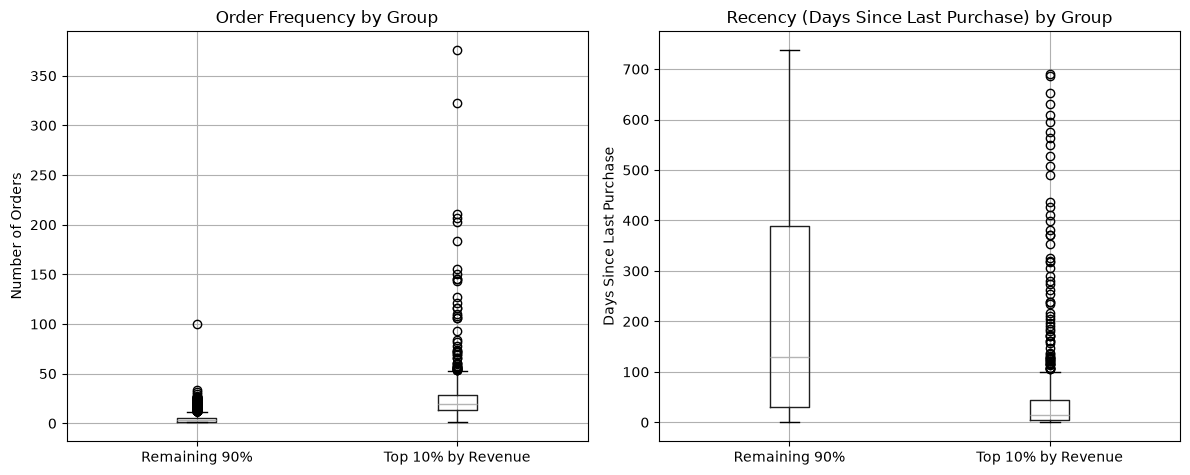

In [9]:
# Build a combined dataframe for plotting, labeling each customer as "Top 10%" or "Rest"
comparison_df = pd.DataFrame({
    'Frequency': frequency_per_customer,
    'Recency': recency_days
})
comparison_df['Group'] = np.where(
    comparison_df.index.isin(top_revenue_customers), 'Top 10% by Revenue', 'Remaining 90%'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Frequency comparison
comparison_df.boxplot(column='Frequency', by='Group', ax=axes[0])
axes[0].set_title('Order Frequency by Group')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xlabel('')

# Recency comparison
comparison_df.boxplot(column='Recency', by='Group', ax=axes[1])
axes[1].set_title('Recency (Days Since Last Purchase) by Group')
axes[1].set_ylabel('Days Since Last Purchase')
axes[1].set_xlabel('')

plt.suptitle('')  # remove the default matplotlib "Boxplot grouped by..." title
plt.tight_layout()
plt.show()

The box plots visually confirm the patterns identified above. The top revenue decile shows a markedly higher and more spread-out Frequency distribution compared to the tightly clustered, low-frequency "Remaining 90%" group. For Recency, the pattern inverts: the top revenue decile's box sits low and compact near zero, indicating consistently recent activity, while the remaining customers show a much wider and higher spread, reflecting longer, more variable gaps since their last purchase. The outlier points in each plot which means extremely high-frequency wholesalers, and a handful of previously

### Quantity & Price Distributions

We examine the distribution of `Quantity` and `Price` at the transaction level to understand typical purchase sizes and prices, and to check for extreme outliers that could distort later aggregations (e.g., Monetary value per customer).

In [10]:
df_clean[['Quantity', 'Price']].describe()

,Quantity,Price
count,776641.000000,776641.000000
mean,13.518268,2.939878
std,146.090716,4.424406
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,649.500000


Both `Quantity` and `Price` show heavy right-skew, consistent with patterns observed elsewhere in this dataset. The median transaction involves 6 units at £1.95 per unit, but both columns have extreme maximum values (80,995 units; £10,953.50 per unit) far beyond the 75th percentile. These outliers warrant closer inspection before proceeding, to distinguish genuine large-scale wholesale transactions from potential data quality issues.

In [11]:
# Top 10 transactions by Quantity
df_clean.nlargest(10, 'Quantity')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID', 'Country']]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
776180,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom
421863,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom
62424,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0,Denmark
90199,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0,Denmark
90201,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0,Denmark
90202,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,13902.0,Denmark
90200,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,13902.0,Denmark
96564,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,17940.0,United Kingdom
96565,502269,21982,PACK OF 12 SUKI TISSUES,10000,0.25,17940.0,United Kingdom
96566,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,0.25,17940.0,United Kingdom


In [12]:
# Top 10 transactions by Price
df_clean.nlargest(10, 'Price')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID', 'Country']]

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
538438,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,15098.0,United Kingdom
538447,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,649.50,15098.0,United Kingdom
47408,495802,ADJUST,Adjustment by john on 26/01/2010 17,1,387.54,12748.0,United Kingdom
186199,513566,ADJUST2,Adjustment by Peter on Jun 25 2010,1,358.47,17364.0,United Kingdom
47386,495755,ADJUST,Adjustment by john on 26/01/2010 16,1,342.80,14413.0,United Kingdom
186198,513564,ADJUST2,Adjustment by Peter on Jun 25 2010,1,300.13,17050.0,United Kingdom
200972,515349,22656,VINTAGE BLUE KITCHEN CABINET,1,295.00,15513.0,United Kingdom
200973,515349,22655,VINTAGE RED KITCHEN CABINET,1,295.00,15513.0,United Kingdom
202485,515602,22656,VINTAGE BLUE KITCHEN CABINET,1,295.00,14895.0,United Kingdom
203515,515811,22656,VINTAGE BLUE KITCHEN CABINET,1,295.00,15259.0,United Kingdom


Inspecting the extreme values separately reveals an important distinction. The largest `Quantity` values correspond to genuine bulk purchases of low-priced products (e.g., paper craft items, tissue packs), which means : plausible wholesale orders, not data errors. However, the largest `Price` values are dominated by non-product `StockCode` entries: 8 of the top 10 are coded `"M"` (Manual), and one is `"POST"` (Postage), which seem to be administrative or adjustment entries rather than genuine merchandise sales. These slipped past our earlier cleaning filters, which only checked `Quantity > 0` and `Price > 0` without validating `StockCode` itself. Left uncorrected, these entries would inflate Monetary values for the specific customers associated with them.

*Note: the non-product `StockCode` entries identified above were originally removed here during this exploratory analysis. That fix has since been moved upstream into `1_dataprep.ipynb`, so `df_clean` (loaded at the top of this notebook) is already fully cleaned by this point.*

Having removed non-product `StockCode` entries, we now visualize the `Quantity` and `Price` distributions on the cleaned data. As with orders-per-customer, both are expected to be heavily right-skewed, so we use a zoomed view alongside the full range to make the typical range of values visible.

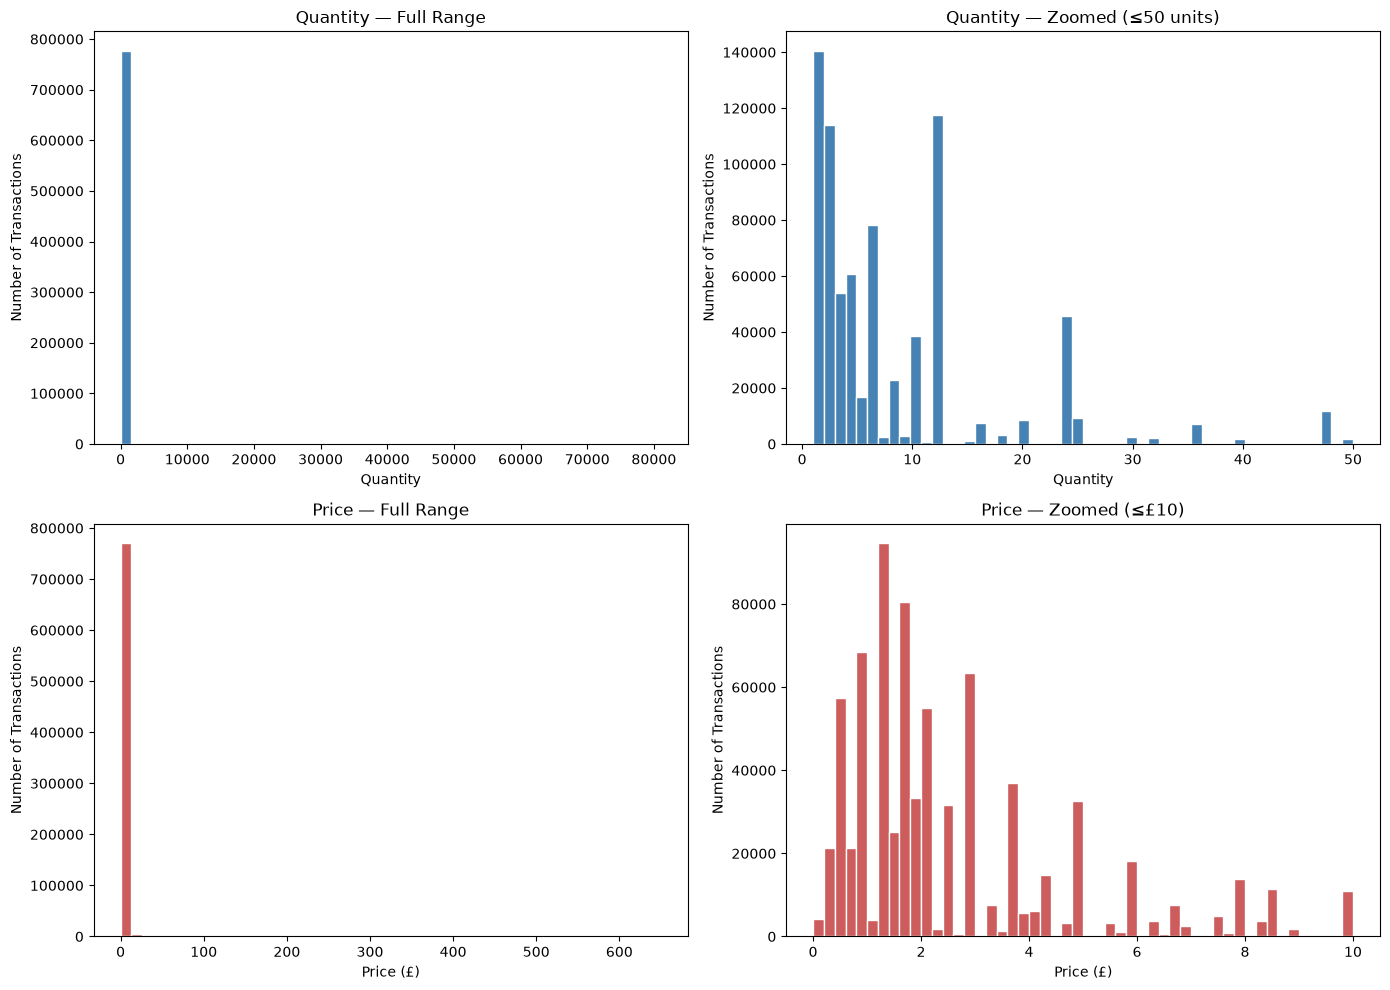

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Quantity - full range
axes[0, 0].hist(df_clean['Quantity'], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Quantity — Full Range")
axes[0, 0].set_xlabel("Quantity")
axes[0, 0].set_ylabel("Number of Transactions")

# Quantity - zoomed (0–50 units, where most transactions fall)
axes[0, 1].hist(df_clean[df_clean['Quantity'] <= 50]['Quantity'], bins=50, color="steelblue", edgecolor="white")
axes[0, 1].set_title("Quantity — Zoomed (≤50 units)")
axes[0, 1].set_xlabel("Quantity")
axes[0, 1].set_ylabel("Number of Transactions")

# Price - full range
axes[1, 0].hist(df_clean['Price'], bins=50, color="indianred", edgecolor="white")
axes[1, 0].set_title("Price — Full Range")
axes[1, 0].set_xlabel("Price (£)")
axes[1, 0].set_ylabel("Number of Transactions")

# Price - zoomed (£0–£10, where most transactions fall)
axes[1, 1].hist(df_clean[df_clean['Price'] <= 10]['Price'], bins=50, color="indianred", edgecolor="white")
axes[1, 1].set_title("Price — Zoomed (≤£10)")
axes[1, 1].set_xlabel("Price (£)")
axes[1, 1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

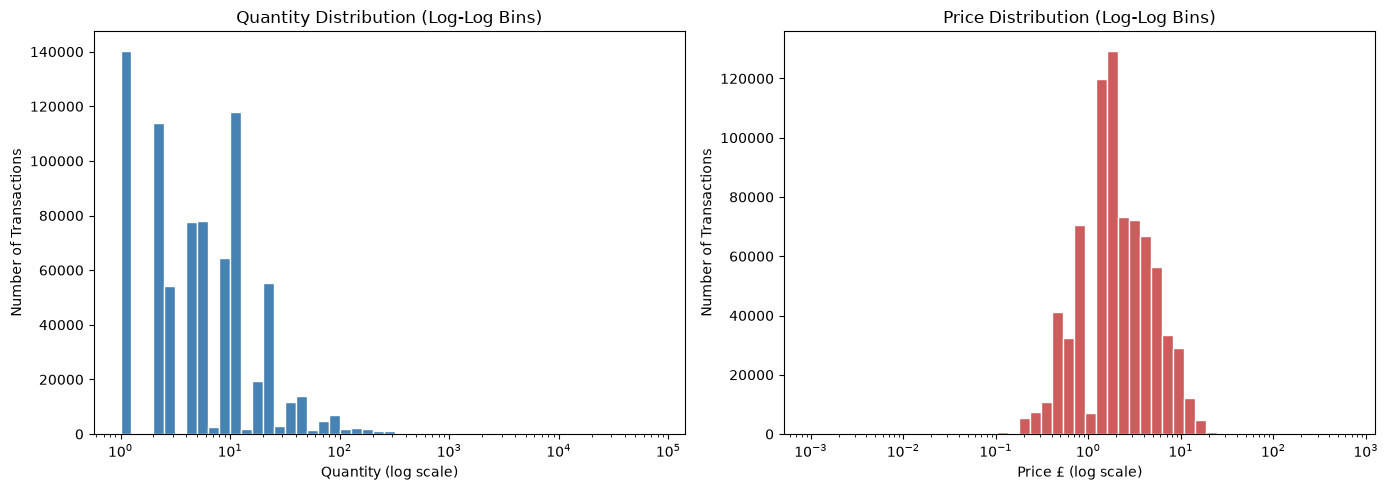

In [14]:
# Use log-spaced bin edges (not just a log-scaled axis) so the histogram
# actually resolves structure across orders of magnitude, rather than
# collapsing into one or two oversized linear bins
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qty_bins = np.logspace(np.log10(df_clean['Quantity'].min()), np.log10(df_clean['Quantity'].max()), 50)
axes[0].hist(df_clean['Quantity'], bins=qty_bins, color="steelblue", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_title("Quantity Distribution (Log-Log Bins)")
axes[0].set_xlabel("Quantity (log scale)")
axes[0].set_ylabel("Number of Transactions")

price_bins = np.logspace(np.log10(df_clean['Price'].min()), np.log10(df_clean['Price'].max()), 50)
axes[1].hist(df_clean['Price'], bins=price_bins, color="indianred", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Price Distribution (Log-Log Bins)")
axes[1].set_xlabel("Price £ (log scale)")
axes[1].set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

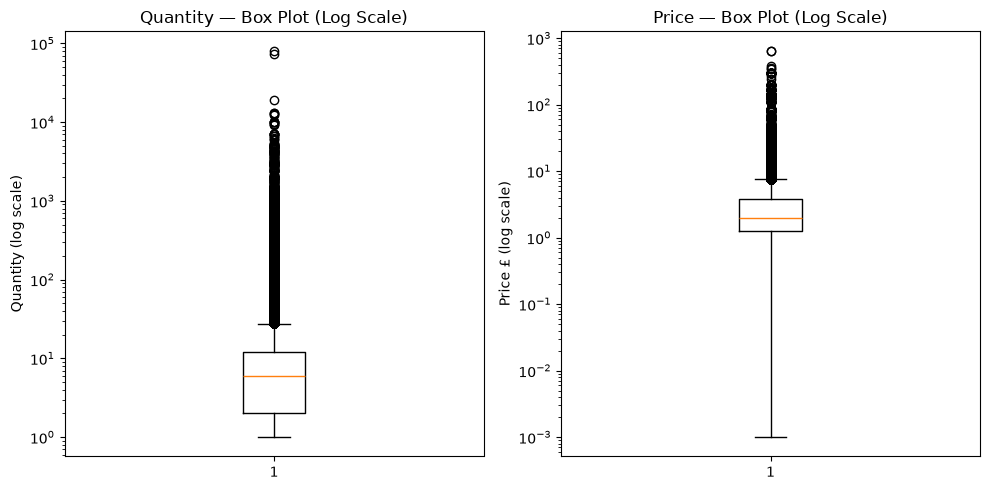

In [15]:
# Box plots summarize median, quartiles, and outliers in a single compact view,
# which is often clearer than a histogram for heavily skewed data with extreme outliers
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Quantity box plot (log scale y-axis, since outliers span several orders of magnitude)
axes[0].boxplot(df_clean['Quantity'], orientation='vertical')
axes[0].set_yscale("log")
axes[0].set_title("Quantity — Box Plot (Log Scale)")
axes[0].set_ylabel("Quantity (log scale)")

# Price box plot (log scale y-axis, same reasoning)
axes[1].boxplot(df_clean['Price'], orientation='vertical')
axes[1].set_yscale("log")
axes[1].set_title("Price — Box Plot (Log Scale)")
axes[1].set_ylabel("Price £ (log scale)")

plt.tight_layout()
plt.show()

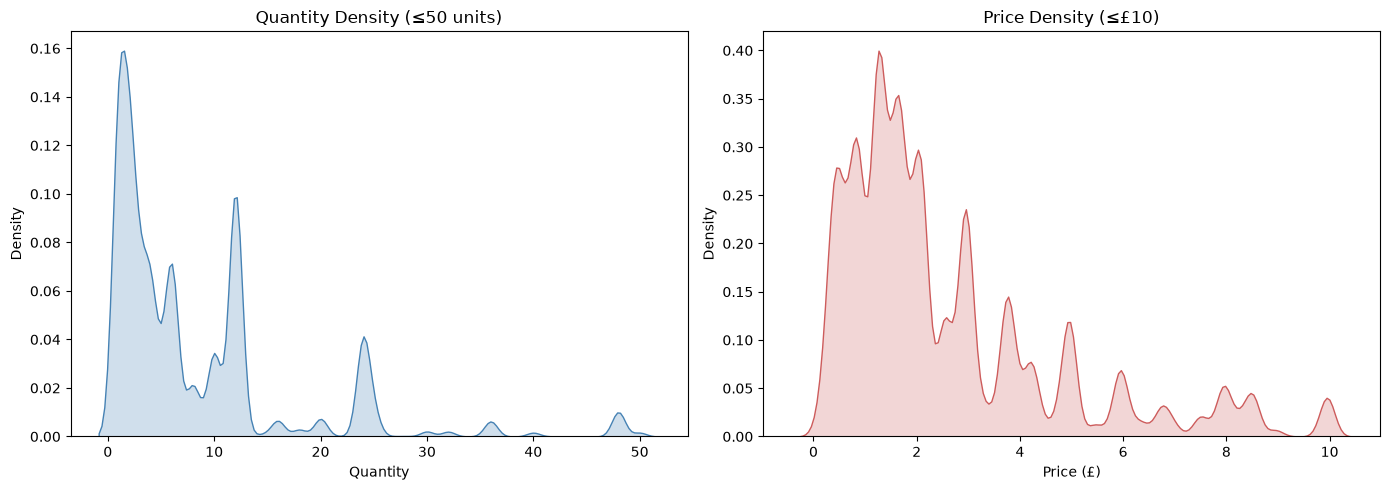

In [16]:
# KDE plots show a smoothed density curve instead of discrete bars,
# useful here since Price has many repeated exact values (e.g. £1.95, £0.42)
# which create a "gappy" look in a standard histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantity KDE, restricted to a reasonable range for readability
sns.kdeplot(df_clean[df_clean['Quantity'] <= 50]['Quantity'], ax=axes[0], color="steelblue", fill=True)
axes[0].set_title("Quantity Density (≤50 units)")
axes[0].set_xlabel("Quantity")

# Price KDE, restricted similarly
sns.kdeplot(df_clean[df_clean['Price'] <= 10]['Price'], ax=axes[1], color="indianred", fill=True)
axes[1].set_title("Price Density (≤£10)")
axes[1].set_xlabel("Price (£)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()


We examined `Quantity` and `Price` using four complementary visualizations, each highlighting a different aspect of the data:

- **Standard histograms (full range vs. zoomed):** The full-range view is almost unreadable, since a handful of extreme outliers (up to 80,995 units, £10,953.50 per unit) compress everything else into a single bar. The zoomed views (≤50 units, ≤£10) show where most transactions actually fall, but the bars appear "gappy" due to common fixed prices and pack sizes.
- **Log-scale histograms:** Using log-spaced bins solves the full-range problem directly, showing the entire dataset in one chart without needing a separate zoomed view. This reveals clear clusters in `Quantity` around common pack sizes (roughly 1, 3, 6, 12, and 24 units), and a smooth, roughly bell-shaped spread in `Price` centered around £1–3, tapering off gradually toward higher values.
- **Box plots (log scale):** These summarize the same information numerically such as median, interquartile range, and outliers, in a single compact chart. Both variables show a fairly narrow "typical" range (the box) with a long vertical scatter of outlier points above it, confirming that extreme values exist but are relatively rare.
- **KDE (density) plots:** These smooth out the histogram's bar-like shape and make the underlying pattern easier to see. Both `Quantity` and `Price` show multiple distinct peaks rather than one smooth curve, reinforcing that purchase quantities and prices cluster around specific common values rather than varying randomly.

 `Quantity` and `Price` are both heavily right-skewed, with a small number of very large wholesale-style transactions pulling the average well above the typical value. At the same time, the data isn't simply "random with outliers", i.e., the repeated peaks across all four views point to structured retail conventions: standard pack sizes (6, 12, 24 units) and round-number pricing (£1.25, £1.95, £2.95, etc.). This distinction matters going forward: extreme values are genuine business activity (large wholesale orders) rather than data errors, but their scale means they'll need careful handling when we aggregate `Quantity` and `Price` into Monetary value for the RFM table and later CLV models.

### Time Range & Trends

We examine the dataset's full date span and transaction volume over time. This helps confirm overall time coverage, identify any seasonality (e.g., holiday spikes typical of gift-ware retail), and informs the reference date we'll use for Recency in the RFM table.

In [17]:
# Confirm the full date range covered by the dataset
print("Earliest transaction:", df_clean['InvoiceDate'].min())
print("Latest transaction:", df_clean['InvoiceDate'].max())

Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2011-12-09 12:50:00


We aggregate transactions by month to visualize volume trends over the two-year period. This helps identify any seasonality (e.g., a holiday-driven spike, given the retailer's gift-ware focus) and provides context for interpreting customer behavior later.

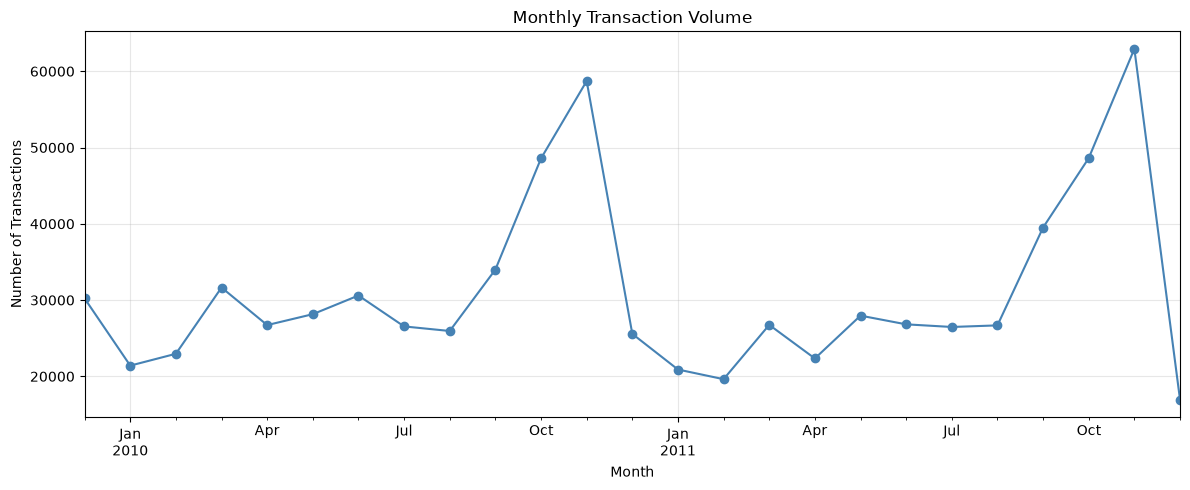

In [18]:
# Extract year-month period from InvoiceDate for monthly aggregation
monthly_transactions = df_clean.set_index('InvoiceDate').resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_transactions.plot(kind='line', marker='o', ax=ax, color="steelblue")

ax.set_title("Monthly Transaction Volume")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Transactions")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Monthly transaction volume shows clear seasonality, with a strong rise beginning around August/September and peaking sharply in October–November each year, which is consistent with pre-holiday gift-ware purchasing, particularly among wholesale buyers stocking up ahead of Christmas. The 2011 peak (~63,000 transactions) exceeds the 2010 peak (~59,000), suggesting overall business growth across the two-year period rather than a flat repeating cycle. The sharp final drop shown for December 2011 is **not a genuine decline**, since the dataset's last recorded transaction is December 9, 2011, so this final data point reflects a partial month only and should be interpreted accordingly.

The chart above counts transaction line items per month, not distinct orders. To confirm the seasonality reflects genuine order volume (rather than, say, larger orders with more line items during peak season), we recompute the trend using distinct `Invoice` counts per month instead.

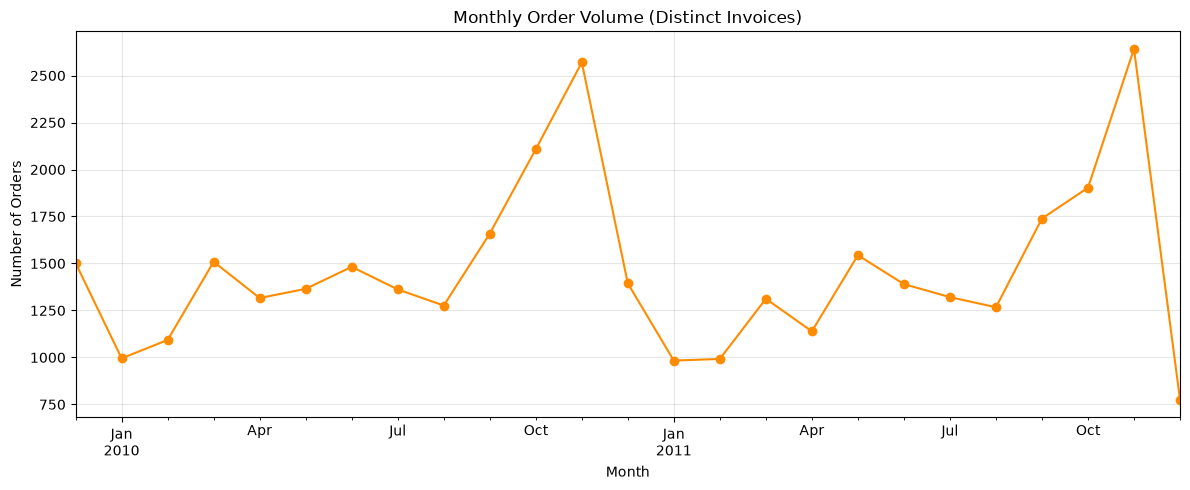

In [19]:
# Count distinct invoices (orders) per month, rather than transaction line items
monthly_orders = df_clean.set_index('InvoiceDate').resample('ME')['Invoice'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', ax=ax, color="darkorange")

ax.set_title("Monthly Order Volume (Distinct Invoices)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The monthly order count (distinct invoices) closely mirrors the transaction line-item trend shown earlier : the same seasonal rise, October–November peak, and year-over-year growth pattern. This confirms the seasonality reflects genuine changes in order volume (more distinct orders placed during peak season), rather than an artifact of orders simply containing more line items at certain times of year. As before, the sharp final drop corresponds to the partial final month (December 1–9, 2011) and does not represent a real decline.

### Reference Date Decision

For the RFM table, Recency will be calculated as the number of days between each customer's most recent purchase and a fixed reference date. Following standard convention, we set the reference date as **one day after the dataset's last recorded transaction**, i.e., **2011-12-10**. This ensures every customer has a non-negative Recency value (since no customer can have purchased after the reference date), and treats the analysis as if it were being conducted "as of" the day immediately following the dataset's collection window.

In [20]:
# Reference date for Recency calculations: one day after the dataset's last transaction,
# normalized to midnight for a clean whole-day reference point
reference_date = (df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)).normalize()
reference_date

Timestamp('2011-12-10 00:00:00')

### Geographic Breakdown

We examine the distribution of transactions and customers by `Country`. Given the dataset description (a UK-based retailer with international wholesale customers), we expect the United Kingdom to dominate by volume, but it's worth quantifying this and identifying which other countries have a meaningful presence.

In [21]:
# Transaction line-item count by country
df_clean['Country'].value_counts().head(15)

Country
United Kingdom     699649
Germany             15791
EIRE                15360
France              13033
Netherlands          4981
Spain                3563
Switzerland          2951
Belgium              2911
Portugal             2296
Australia            1783
Channel Islands      1544
Italy                1412
Sweden               1267
Norway               1263
Cyprus               1132
Name: count, dtype: int64

Transaction volume is overwhelmingly concentrated in the United Kingdom (699,649 transactions, ~90% of the dataset), consistent with the retailer's UK base. The next largest countries are Germany, EIRE (Ireland), and France, where each account for under 2% of total volume, with a long tail of smaller international markets beyond that. This strong UK concentration is an important limitation to note: any patterns or models derived from this dataset will primarily reflect UK customer behavior, and results may not generalize well to other regions given the limited international sample size.

In [22]:
# Distinct customer count by country
df_clean.groupby('Country')['Customer ID'].nunique().sort_values(ascending=False).head(15)

Country
United Kingdom     5336
Germany             107
France               94
Spain                41
Belgium              29
Portugal             24
Netherlands          22
Switzerland          22
Sweden               19
Italy                17
Australia            15
Finland              14
Austria              13
Channel Islands      13
Denmark              12
Name: Customer ID, dtype: int64

The customer-level view reveals an important distinction from the transaction-level view: while the United Kingdom still dominates by far (5,336 of 5,878 total customers, ~91%), the ranking of other countries shifts. Notably, EIRE (Ireland) is the third-largest country by transaction volume, it does not appear in the top 15 by distinct customer count, suggesting a very small number of Ireland-based customers account for a disproportionately large share of transactions (consistent with high-frequency wholesale buying, similar to the pattern observed earlier in the customer/revenue concentration analysis). This reinforces that transaction volume alone can be a misleading proxy for market breadth, since, a country can have many transactions concentrated in very few customers.

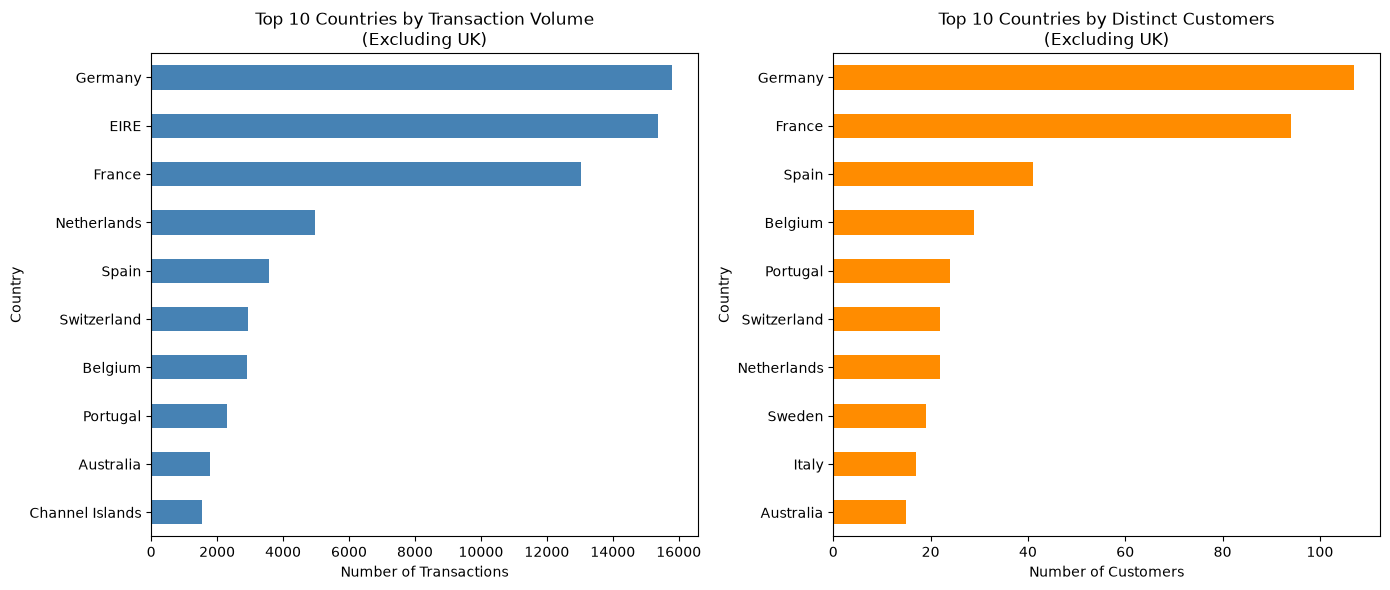

In [23]:
# Get top 10 countries by transaction count and by customer count (excluding UK, since it dwarfs everything else)
top_countries_by_txn = df_clean[df_clean['Country'] != 'United Kingdom']['Country'].value_counts().head(10)
top_countries_by_customers = df_clean[df_clean['Country'] != 'United Kingdom'].groupby('Country')['Customer ID'].nunique().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_countries_by_txn.plot(kind='barh', ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Countries by Transaction Volume\n(Excluding UK)")
axes[0].set_xlabel("Number of Transactions")
axes[0].invert_yaxis()  # highest value at the top

top_countries_by_customers.plot(kind='barh', ax=axes[1], color="darkorange")
axes[1].set_title("Top 10 Countries by Distinct Customers\n(Excluding UK)")
axes[1].set_xlabel("Number of Customers")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [25]:
# Aggregate total revenue by country (needed for both choropleth map variants below)
revenue_by_country = df_clean.groupby('Country')['Revenue'].sum().reset_index()

In [26]:
# Add a log-transformed revenue column for better color differentiation
revenue_by_country['Log Revenue'] = np.log10(revenue_by_country['Revenue'] + 1)

fig = px.choropleth(
    revenue_by_country,
    locations="Country",
    locationmode="country names",
    color="Log Revenue",
    color_continuous_scale="Blues",
    hover_name="Country",
    hover_data={"Revenue": ":.0f", "Log Revenue": False},  # show actual revenue on hover, hide log value
    title="Total Revenue by Country (Log Scale)"
)

fig.update_layout(width=1000, height=600)
fig.show()

In [27]:
revenue_excl_uk = revenue_by_country[revenue_by_country['Country'] != 'United Kingdom']

fig2 = px.choropleth(
    revenue_excl_uk,
    locations="Country",
    locationmode="country names",
    color="Revenue",
    color_continuous_scale="Oranges",
    hover_name="Country",
    title="Total Revenue by Country (Excluding UK)"
)

fig2.update_layout(width=1000, height=600)
fig2.show()

Both map variants confirm and refine the earlier findings. The log-scale map (including the UK) reveals a secondary tier of Western and Northern European markets such as Germany, France, Netherlands, Belgium, and Switzerland, plus a notable standout in Australia, which shows meaningful revenue despite being geographically isolated from the retailer's other markets. The UK-excluded map confirms Germany and France as the clear leaders among international markets, forming a visible cluster in Western Europe. Beyond this core European (plus Australian) footprint, the retailer has negligible presence across the Americas, Asia, and Africa. This geographic concentration reinforces the earlier limitation noted in the transaction-level breakdown: the dataset and any models built from it, primarily reflect UK and Western European purchasing behavior.

### Building the RFM Table

We now formally assemble the RFM (Recency, Frequency, Monetary) feature table : one row per customer, aggregated from the fully cleaned `df_clean` dataset. Although we computed similar values earlier during exploratory analysis, those were computed at different points before the final `StockCode` cleaning step. We recompute all three components fresh here, on the final cleaned dataset, to ensure consistency.

- **Recency:** Days between each customer's most recent purchase and the reference date (2011-12-10, one day after the dataset's last transaction).
- **Frequency:** Count of distinct invoices (orders) per customer.
- **Monetary:** Total revenue (`Quantity × Price`) per customer.

In [28]:
# Recency: days since each customer's last purchase, relative to the reference date
last_purchase = df_clean.groupby('Customer ID')['InvoiceDate'].max()
recency = (reference_date - last_purchase).dt.days

# Frequency: distinct invoice count per customer
frequency = df_clean.groupby('Customer ID')['Invoice'].nunique()

# Monetary: total revenue per customer
monetary = df_clean.groupby('Customer ID')['Revenue'].sum()

# Combine into a single RFM table
rfm = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary
})

rfm.shape

(5861, 3)

*Note: the RFM table contains 5,861 customers rather than the 5,878 counted earlier in this notebook. This is expected 17 customers which had transaction histories consisting entirely of non-product `StockCode` entries (postage, manual adjustments), which are excluded during cleaning in `1_dataprep.ipynb`, leaving them with no genuine purchases to include.*

### Sanity Check the RFM Table

We confirm the RFM table has no missing values and that all three features fall within reasonable ranges (e.g., no negative Recency, Frequency, or Monetary values).

In [29]:
# Check for missing values
print("Missing values per column:")
print(rfm.isnull().sum())

# Summary statistics for all three features
rfm.describe()

Missing values per column:
Recency      0
Frequency    0
Monetary     0
dtype: int64


,Recency,Frequency,Monetary
count,5861.000000,5861.000000,5861.000000
mean,200.472957,6.251322,2912.997493
std,209.217206,12.774914,14300.543047
min,0.000000,1.000000,2.950000
25%,25.000000,1.000000,338.130000
50%,95.000000,3.000000,854.990000
75%,379.000000,7.000000,2237.120000
max,738.000000,376.000000,580987.040000


The RFM table contains no missing values, and all three features fall within sensible ranges i.e., no negative values, and the scale of each feature (Recency up to 738 days, Frequency up to 376 orders, Monetary up to £580,987) is consistent with the skew and concentration patterns identified throughout this notebook's exploratory analysis. This confirms the table was constructed correctly and is ready to be saved as a checkpoint for feature engineering and modeling.

In [30]:
# Save the RFM table as a checkpoint for downstream feature engineering and modeling
rfm.to_csv("../data/rfm_table.csv")

## Summary

This notebook explored the cleaned Online Retail II dataset (`online_retail_clean.csv`, 779,425 transactions) across five areas, with an additional cleaning correction discovered along the way, before building the formal RFM feature table.

**Key findings:**

- **Customer Overview:** 5,878 unique customers, with a heavily right-skewed order frequency distribution (median 3 orders, mean 6.29, max 398) — consistent with a mix of occasional retail buyers and high-frequency wholesalers.
- **Revenue Concentration:** Just 4.4% of customers generate 50% of total revenue, and 23% generate 80% — a stronger-than-typical Pareto pattern, visually confirmed with a Lorenz curve. The top revenue decile also orders far more frequently (median 19 vs. 3 orders) and more recently (median 15 vs. 129 days) than the remaining customer base, though the overlap between "high revenue" and "high frequency" is not perfect — validating the use of all three RFM dimensions rather than revenue alone.
- **Quantity & Price Distributions:** Both features are heavily right-skewed with genuine large-scale outliers (bulk wholesale orders). Multiple visualization approaches (log-scale histograms, box plots, KDE plots) revealed structured clustering around common pack sizes and round-number pricing, rather than purely random variation.
- **Data Quality Correction:** Investigation of extreme `Price` outliers uncovered 2,784 rows (~0.36%) of non-product `StockCode` entries (postage, manual adjustments, bank charges) that had slipped past the original cleaning filters in `1_dataprep.ipynb`. These were removed, which in turn caused 17 customers — whose entire transaction history consisted of these non-product entries — to be excluded from the dataset entirely, a discrepancy that was investigated and confirmed as correct.
- **Time Range & Trends:** The dataset spans 2009-12-01 to 2011-12-09. Both transaction volume and distinct order counts show consistent seasonality, peaking each October–November (consistent with pre-holiday gift-ware demand) and growing year-over-year. A reference date of 2011-12-10 was set for Recency calculations.
- **Geographic Breakdown:** The United Kingdom dominates (~90% of transactions and customers), with Germany, France, and EIRE as the largest international markets by different measures (transaction volume vs. distinct customers), plus a notable standout market in Australia. This UK/Western-Europe concentration is a limitation to note for any modeling built on this data.

**Output:** A clean RFM feature table (`rfm_table.csv`) containing 5,861 customers with `Recency`, `Frequency`, and `Monetary` columns, ready for feature engineering and modeling (Regression → Classification → Clustering).